### WFCRL: A Benchmark and Interfacing tool to evaluate Reinforcement Learning Solutions for Wind Farm Control

A standard Python 3 kernel is sufficient (no special MPI kernel needed).
`FastFarmStandaloneInterface` runs FAST.Farm as a subprocess.

In [1]:
# Add project root to path
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

# FastFarmStandaloneInterface runs FAST.Farm as a subprocess (no MPI needed)
print("✓ Running with FastFarmStandaloneInterface (subprocess-based)")
print("✓ FLORIS environments available for quick testing")
print(f"wfcrl available: {os.path.isdir(os.path.join(os.getcwd(), '..', 'wfcrl'))}")

✓ Running with FastFarmStandaloneInterface (subprocess-based)
✓ FLORIS environments available for quick testing
wfcrl available: True


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wfcrl.rewards import StepPercentage
from wfcrl import environments as envs
from wfcrl.environments.data_cases import named_cases_dictionary
from wfcrl.interface import FastFarmStandaloneInterface

sns.set_theme(style="darkgrid")

Let's look at a simple environment of 7 turbines, inspired by the real wind farm of Ablaincourt, in Northern France. 

In [3]:
env = envs.make("DafengH1_Floris", max_num_steps=70)
print(env.num_turbines)

24


Our environment has 7 turbines. Its `action_space` defines the changes in actuators that can be made to influence the production of turbines, and its `observation_space` gives us of list of observed measures and the spaces they take value in.

In [4]:
print(env.action_space)
print(env.observation_space)

Dict('yaw': Box(-5.0, 5.0, (24,), float32))
Dict('yaw': Box(-40.0, 40.0, (24,), float32), 'freewind_measurements': Box([3. 0.], [ 28. 360.], (2,), float32), 'wind_speed': Box(3.0, 28.0, (24,), float32), 'wind_direction': Box(0.0, 360.0, (24,), float32))


Here, we see that we can control the yaws of all 7 turbines, and we observe:
* The velocity of the undisturbed wind at the entrance of the farm, between 3 and 28 m/s
* The direction of the undisturbed wind at the entrance of the farm, between 0 and 360°.
* The current yaw commands of the system for all 7 turbines, between -20° and 20°.

Let us look at the first observation at initialization:

In [5]:
observation = env.reset()
print(observation)

OrderedDict({'yaw': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.]), 'freewind_measurements': array([  9.20887047, 260.83562305]), 'wind_speed': array([9.15951002, 8.43748173, 8.45329517, 8.4949489 , 8.42161845,
       8.67147366, 8.18883329, 9.15951002, 9.15951002, 9.15951002,
       8.69966935, 8.6736705 , 8.65109842, 8.62020233, 8.47480773,
       8.5016896 , 9.08475118, 9.15951002, 8.51370257, 8.41463782,
       8.39450151, 8.38749504, 8.38437655, 9.13300079]), 'wind_direction': array([261.15275263, 261.33426658, 261.38131799, 261.39516282,
       261.42722334, 261.37070288, 261.4961275 , 261.15079015,
       261.13326034, 261.14680348, 261.29933469, 261.34281738,
       261.36856364, 261.38808635, 261.4173581 , 261.4824491 ,
       261.23310001, 261.15185543, 261.31221228, 261.36647447,
       261.39138341, 261.40438034, 261.4120723 , 261.25320796])})


d:\HR_Project\wfcrl-env-HRL\.venv\Lib\site-packages\floris\core\flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


Let's implement a simple step policy, that makes every turbine in the field yaw one by one.

In [6]:
def step_policy(i):
    joint_action = {"yaw": np.zeros((env.num_turbines))}
    turb_idx = (i // 5) % env.num_turbines
    if i % 5 == 0:
        joint_action["yaw"][turb_idx] = -5.0
    return joint_action

In [7]:
observation = env.reset()
r = 0
i = 0
done = False
while not done:
    joint_action = step_policy(i)
    observation, reward, termination, truncation, info = env.step(joint_action)
    r += reward
    i += 1
    done = termination or truncation
print(f"Total reward = {r}")

Total reward = [446.3479445]


We can retrieve information about the evolution of the wind farm in `env.history`

In [8]:
# Prepare plots
columns = [f"T{i+1}" for i in range(env.num_turbines)]
yaws = pd.DataFrame(np.c_[[h["yaw"] for h in env.history["observation"]]], columns=columns)
powers = pd.DataFrame(np.c_[[h for h in env.history["power"]]], columns=columns)

In [9]:
yaws.tail()

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T15,T16,T17,T18,T19,T20,T21,T22,T23,T24
64,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[Text(0, 0.5, 'Power (MW)'), Text(0.5, 0, 'Iterations')]

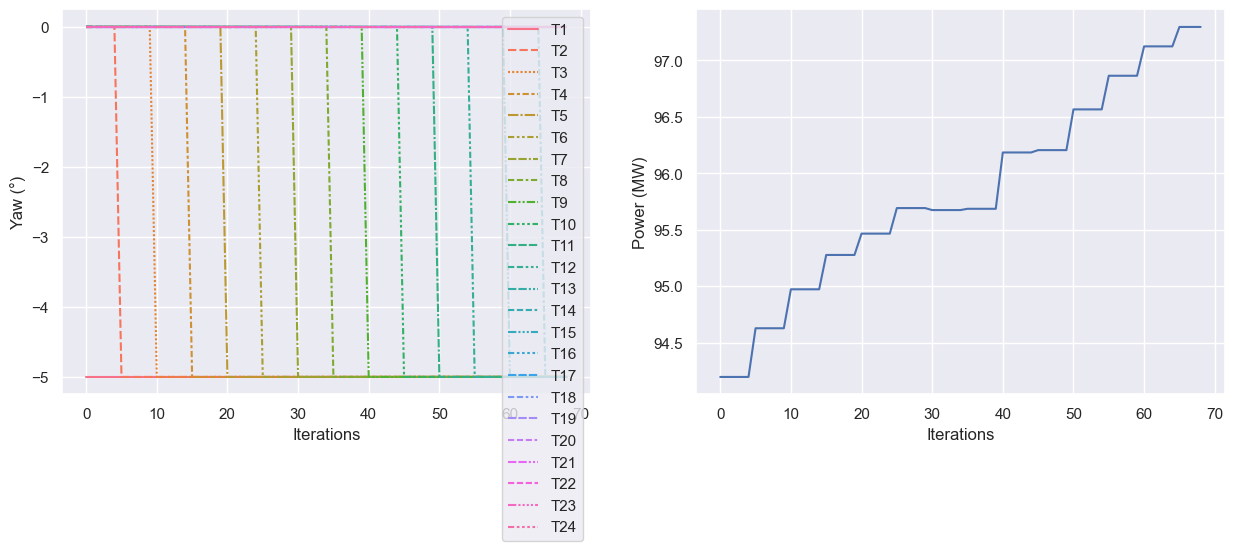

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
ax0 = sns.lineplot(yaws, ax=ax[0])
ax1 = sns.lineplot(powers.sum(1), ax=ax[1])
ax0.set(ylabel="Yaw (°)", xlabel="Iterations")
ax1.set(ylabel="Power (MW)", xlabel="Iterations")

### Decentralized Control

The wind farm control environment also exists in a Decentralized Control environment based on [`PettingZoo`](https://pettingzoo.farama.org/). We can access it by adding `Dec_` in front of the environment's name.

In [11]:
env = envs.make("Dec_DafengH1_Floris", max_num_steps=70)
env.reset()
print(env.num_turbines)
print(env.agents)

24
['turbine_1', 'turbine_2', 'turbine_3', 'turbine_4', 'turbine_5', 'turbine_6', 'turbine_7', 'turbine_8', 'turbine_9', 'turbine_10', 'turbine_11', 'turbine_12', 'turbine_13', 'turbine_14', 'turbine_15', 'turbine_16', 'turbine_17', 'turbine_18', 'turbine_19', 'turbine_20', 'turbine_21', 'turbine_22', 'turbine_23', 'turbine_24']


d:\HR_Project\wfcrl-env-HRL\.venv\Lib\site-packages\floris\core\flow_field.py:169: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  * np.power(


This is a **multi-agent environment**, where every turbine is represented by an agent. 

Let's define 7 different individual policies

In [12]:
def step_policy(i, j):
    return {"yaw": np.float32(-5.0)} if i%(4*(j+1)) == 0 else {"yaw": np.float32(0.0)}
def multi_agent_step_routine(env, policy):
    r = {agent: 0 for agent in env.possible_agents}
    done = {agent: False for agent in env.possible_agents}
    num_steps = {agent: 0 for agent in env.possible_agents}
    for agent in env.agent_iter():
        observation, reward, termination, truncation, info = env.last()
        done[agent] = done[agent] or termination or truncation
        r[agent] += reward
        if done[agent]:
            action = None
        else:
            action = policy(num_steps[agent], env.agent_name_mapping[agent])
            num_steps[agent] += 1
        env.step(action)
    return r

In [13]:
env.reset()
rewards = multi_agent_step_routine(env, step_policy)
print(f"Total rewards = {rewards}")

Total rewards = {'turbine_1': array([767.6211002]), 'turbine_2': array([767.6211002]), 'turbine_3': array([767.6211002]), 'turbine_4': array([767.6211002]), 'turbine_5': array([767.6211002]), 'turbine_6': array([767.6211002]), 'turbine_7': array([767.6211002]), 'turbine_8': array([767.6211002]), 'turbine_9': array([767.6211002]), 'turbine_10': array([767.6211002]), 'turbine_11': array([767.6211002]), 'turbine_12': array([767.6211002]), 'turbine_13': array([767.6211002]), 'turbine_14': array([767.6211002]), 'turbine_15': array([767.6211002]), 'turbine_16': array([767.6211002]), 'turbine_17': array([767.6211002]), 'turbine_18': array([767.6211002]), 'turbine_19': array([767.6211002]), 'turbine_20': array([767.6211002]), 'turbine_21': array([767.6211002]), 'turbine_22': array([767.6211002]), 'turbine_23': array([767.6211002]), 'turbine_24': array([767.6211002])}


In [14]:
# Prepare plots
columns = [f"T{i+1}" for i in range(env.num_turbines)]
yaws = np.c_[[[h["yaw"] for h in env.history[agent]["observation"]]for agent in env.possible_agents]].T
powers = np.c_[[env.history[agent]["power"] for agent in env.possible_agents]].T
yaws = pd.DataFrame(yaws, columns=columns)
powers = pd.DataFrame(powers, columns=columns)

[Text(0, 0.5, 'Power (MW)'), Text(0.5, 0, 'Iterations')]

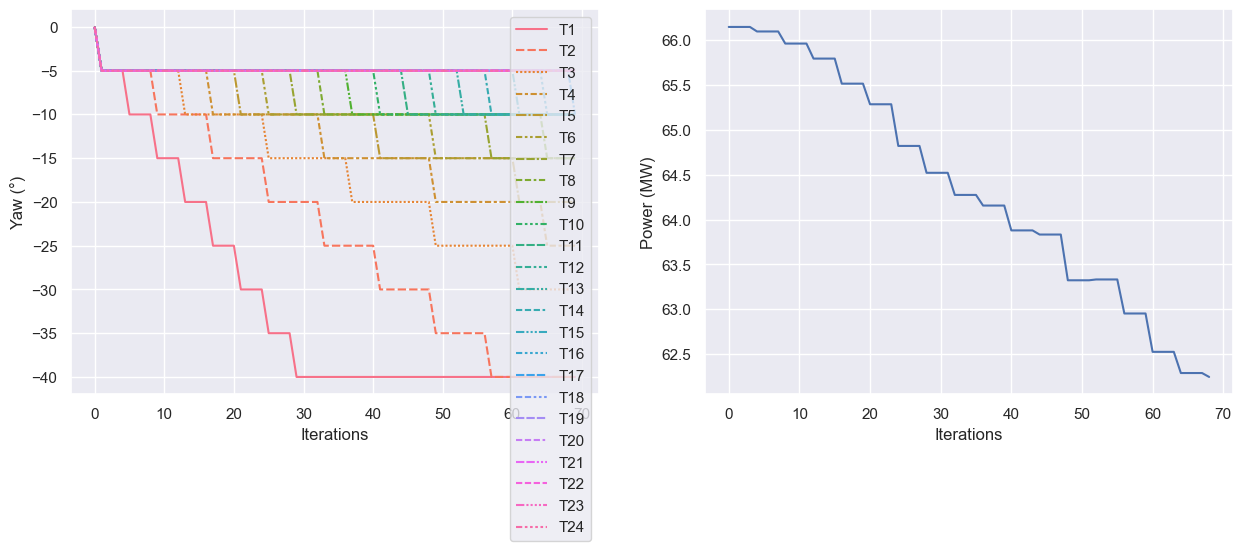

In [15]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
ax0 = sns.lineplot(yaws, ax=ax[0])
ax1 = sns.lineplot(powers.sum(1), ax=ax[1])
ax0.set(ylabel="Yaw (°)", xlabel="Iterations")
ax1.set(ylabel="Power (MW)", xlabel="Iterations")

### Interfacing with FastFarm via FastFarmStandaloneInterface

`FastFarmStandaloneInterface` runs FAST.Farm as a subprocess, generates input files automatically, and parses the `.outb` output files for power and load measurements.

In [16]:
# The FLORIS environments use FLORIS as backend
# For FAST.Farm, we use FastFarmStandaloneInterface instead
if hasattr(env, 'mdp') and hasattr(env.mdp, 'interface'):
    print(f"FLORIS backend: {type(env.mdp.interface).__name__}")
else:
    print("Standard Gymnasium environment")

FLORIS backend: FlorisInterface


FLORIS is a steady-state simulator. For dynamic wake simulations, `FastFarmStandaloneInterface` provides a FAST.Farm backend that runs the full OpenFAST-based wind farm simulation as a subprocess.

In [17]:
# Create a FAST.Farm case using the standalone interface
farm_case = named_cases_dictionary["DafengH1_"][0]
config = farm_case.dict()
config["max_iter"] = 5
config["dt"] = 3
config["speed"] = 10

import tempfile
out_dir = os.path.join(tempfile.gettempdir(), "wfcrl_demo_fastfarm")
ff = FastFarmStandaloneInterface(config, out_dir)
ff.setup()
ff.set_yaw_pitch(0.0, 0.0)
print(f"FAST.Farm case ready ({farm_case.num_turbines} turbines)")

Deltas: [ 2.01534455e-03  2.00536760e-03  2.00536760e-03  2.00536760e-03
  2.00536760e-03  2.00536760e-03  2.00536760e-03  1.50651994e-03
  9.97695324e-04  4.88870709e-04  9.97695324e-04  9.97695324e-04
  9.97695324e-04  9.97695324e-04  9.97695324e-04  1.33691173e-03
  6.68455867e-04 -1.99539065e-05 -1.99539065e-05 -9.97695322e-06
 -9.97695322e-06 -9.97695324e-06  1.13242749e-14 -5.98617194e-05]
Exception has been raise. I put this print statement instead. Check with EB.
Exception: Some Y0_High are not on an integer multiple of the high-res grid
Created FAST.Farm input file: C:\Users\Freeman\AppData\Local\Temp\wfcrl_demo_fastfarm/FarmInputs/Case.fstf
FAST.Farm case ready (24 turbines)


`FastFarmStandaloneInterface` runs FAST.Farm as a standalone subprocess. The interface handles input file generation, execution, and output parsing automatically.

In [18]:
# Run simulation
measurements = ff.run()
if measurements['power_mw'] is not None:
    print(f"Simulation completed: {len(measurements['time'])} time steps")
    print(f"Farm power: {measurements['power_mw'].sum(axis=1).mean():.2f} MW mean")
else:
    print("No power data")

Simulation completed: 151 time steps
Farm power: 60.35 MW mean


In [19]:
if measurements['power_mw'] is not None:
    print(f"Turbines: {ff.n_turbines}")
    print(f"Time steps: {len(measurements['time'])}")
    print(f"Power shape: {measurements['power_mw'].shape}")

Turbines: 24
Time steps: 151
Power shape: (151, 24)


Plot the simulation results:

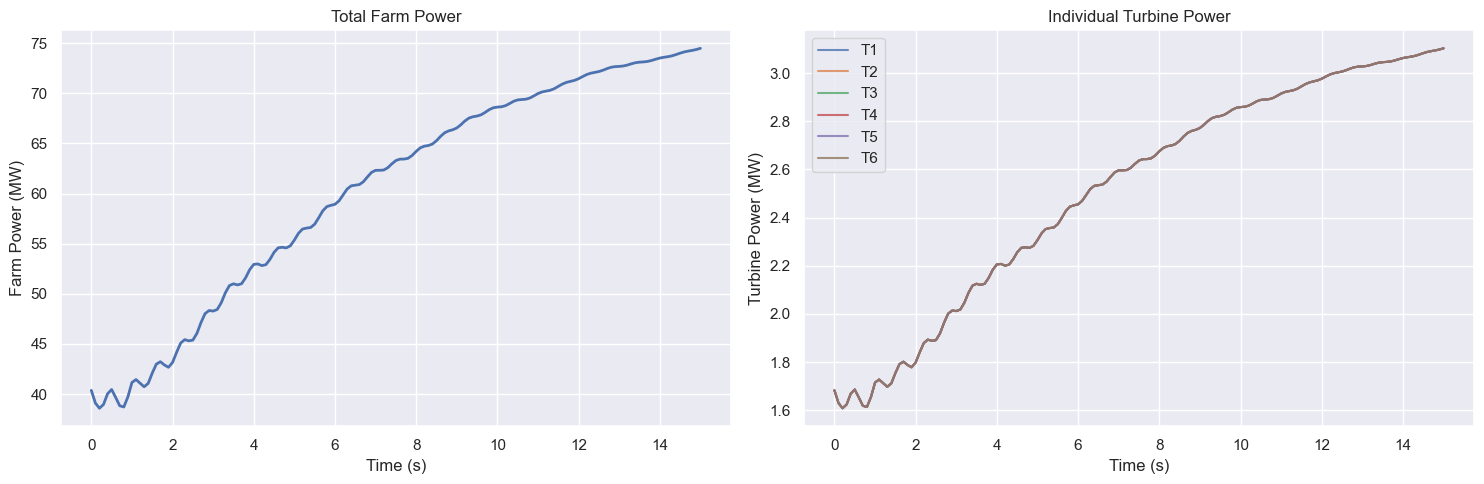

In [20]:
# Plot results
if measurements['power_mw'] is not None:
    time_vec = measurements['time']
    power_mw = measurements['power_mw']
    farm_power = power_mw.sum(axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(time_vec, farm_power, 'b-', lw=2)
    axes[0].set(xlabel="Time (s)", ylabel="Farm Power (MW)", title="Total Farm Power")
    
    for i in range(min(6, power_mw.shape[1])):
        axes[1].plot(time_vec, power_mw[:, i], label=f"T{i+1}", lw=1.5, alpha=0.8)
    axes[1].set(xlabel="Time (s)", ylabel="Turbine Power (MW)", title="Individual Turbine Power")
    axes[1].legend()
    plt.tight_layout()